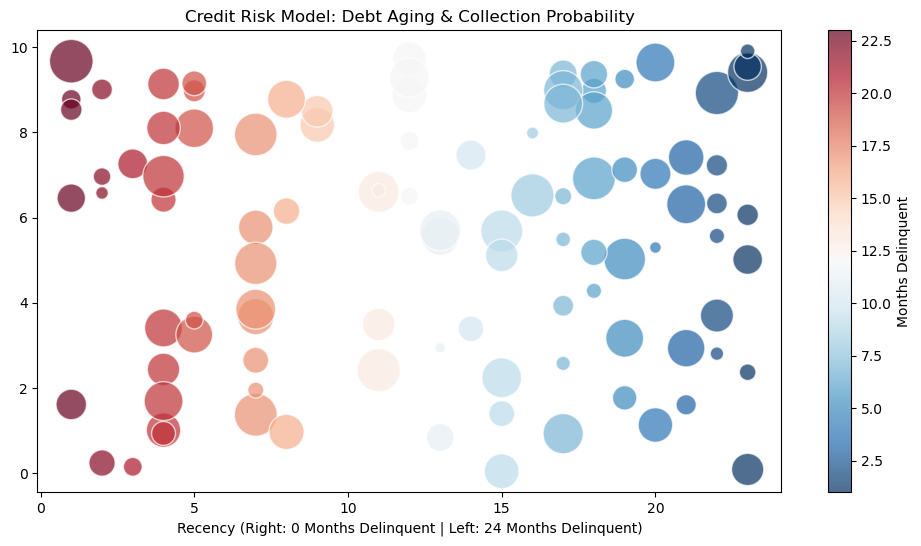

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate Synthetic Data
np.random.seed(42)
num_accounts = 100
debt_owed = np.random.uniform(500, 10000, num_accounts)
months_delinquent = np.random.randint(1, 24, num_accounts)

# Collection probability decreases as debt ages (0% at 24 months)
prob_collection = np.clip(1 - (months_delinquent / 24), 0, 1)

df = pd.DataFrame({
    'debt': debt_owed,
    'months': months_delinquent,
    'prob': prob_collection,
    'x_pos': 24 - months_delinquent, # Right (24) is new, Left (0) is old
    'y_pos': np.random.uniform(0, 10, num_accounts) # Random spread
})

# Visualization
plt.figure(figsize=(12, 6))
# s=size of circle, c=color (RdBu_r colormap for Red-to-Blue)
scatter = plt.scatter(
    df['x_pos'], df['y_pos'], 
    s=df['debt']/10, 
    c=df['months'], 
    cmap='RdBu_r', 
    alpha=0.7, edgecolors='w'
)

plt.title('Credit Risk Model: Debt Aging & Collection Probability')
plt.xlabel('Recency (Right: 0 Months Delinquent | Left: 24 Months Delinquent)')
plt.colorbar(scatter, label='Months Delinquent')
plt.show()